<a href="https://colab.research.google.com/github/Carlogui/IMEC_3345/blob/Tarea_2/Tarea2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<br>

<br>

<br>

<font color='black' align="center"><h1> </h1></font>

<font color='black'><h1 align="center">IMEC 3345 - Sistemas de Conversión de Energía</h1></font>

<font color='black'><h1 align="center">Profesor: Andres Gonzalez Mancera </h1></font>

<font color='black'><h1 align="center">Tarea 2</h1></font>

<font color='black'><h1 align="center">Carlos Ernesto Upegui - 202213004</h1></font>

<br>

<br>

<font color='black'><center>Agosto 20 2025<br>Segundo Semestre 2025 <br>Bogotá DC – Colombia </center><br></font>

In [ ]:
#Librerias para la tarea
import pandas as pd
import numpy as np
import os
from google.colab import drive
import os, glob, re, unicodedata
from pathlib import Path
import datetime
import matplotlib.pyplot as plt
from matplotlib.sankey import Sankey

In [ ]:
#Montar el drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#Dirextorio Colab
BASE_DIR = Path(r"/content/drive/MyDrive/filescolab")

<strong><font color='black'><h1><left> Tarea</left><h1></strong>


</font>

<em><font color='black'><left>Solucion</left></font></em>



In [ ]:
N = 30                               # años

i = 0.07                             # tasa de descuento

capex = 88_000_000                   # COP

incentivo_regional_y0 = 12_200_000   # COP (año 0)

credito_fiscal_y1   = 26_400_000     # COP (año 1)

prod0 = 11_000                       # kWh/año en el año 1

degrad = 0.005                       # 0.5%/year

tarifa0 = 640                        # COP/kWh en el año 1

infl_tarifa = 0.03                   # 3%/año

om_rate0 = 0.003                     # 0.3% del CAPEX en el año 1

om0 = om_rate0 * capex               # COP en el año 1

infl_om = 0.03                       #  3%/año

inv_overhaul = 4_800_000             # COP

overhaul_years = [10, 20]            # años (1- indice)

# funcones
def crf(rate, n):
    return rate*(1+rate)**n / (((1+rate)**n)-1)

def real_series(start, growth, n):
    return np.array([start*((1+growth)**k) for k in range(n)])

def irr(cashflows, guess=0.1, max_iter=200, tol=1e-9):

    r = guess
    for _ in range(max_iter):
        npv_r = sum(cf / ((1+r)**t) for t, cf in enumerate(cashflows))
        d_npv = sum(-t*cf / ((1+r)**(t+1)) for t, cf in enumerate(cashflows) if t > 0)
        if abs(d_npv) < 1e-14:
            break
        r_new = r - npv_r/d_npv
        if not np.isfinite(r_new):
            break
        if abs(r_new - r) < tol:
            r = r_new
            break
        r = r_new
    return r

def first_nonnegative_index(arr):
    idx = np.where(arr >= 0)[0]
    return int(idx[0]) if len(idx) else None


years = np.arange(0, N+1)  # 0..N

 #1..N
prod = np.array([prod0*((1-degrad)**(y-1)) for y in range(1, N+1)])

# O&M
tarifa = real_series(tarifa0, infl_tarifa, N)

om = real_series(om0, infl_om, N)

# ahorro y OPEX
savings = prod * tarifa

opex_net = savings - om

# flujo de caja
cf = np.zeros(N+1)

cf[0] = -capex + incentivo_regional_y0

cf[1:] = opex_net

cf[1] += credito_fiscal_y1

for y in overhaul_years:
    cf[y] -= inv_overhaul

# VPN y TIR
df = np.array([(1+i)**(-y) for y in range(N+1)])

pv_cf = cf * df

npv = pv_cf.sum()

irr_real = irr(cf, guess=0.15)

# Paybacks
cum_cf = np.cumsum(cf)

cum_pv = np.cumsum(pv_cf)

pb_simple_year = first_nonnegative_index(cum_cf)

pb_disc_year   = first_nonnegative_index(cum_pv)

# LCOE
# Con incentivos
costs_with_incent = np.zeros(N+1)

costs_with_incent[0] = capex - incentivo_regional_y0

costs_with_incent[1] = -credito_fiscal_y1

costs_with_incent[1:] += om

for y in overhaul_years:

    costs_with_incent[y] += inv_overhaul

pv_costs_with_incent = (costs_with_incent * df).sum()

pv_energy = (np.r_[0, prod] * df).sum()

lcoe_with_incent = pv_costs_with_incent / pv_energy

# sin incentivos
costs_no_incent = np.zeros(N+1)

costs_no_incent[0] = capex

costs_no_incent[1:] += om

for y in overhaul_years:

    costs_no_incent[y] += inv_overhaul

pv_costs_no_incent = (costs_no_incent * df).sum()

lcoe_no_incent = pv_costs_no_incent / pv_energy

crf_val = crf(i, N)

capex_annualizado = capex * crf_val


# No incentivos
cf_no_incent = np.zeros(N+1)

cf_no_incent[0] = -capex

cf_no_incent[1:] = opex_net

for y in overhaul_years:

    cf_no_incent[y] -= inv_overhaul

pv_cf_no_incent = cf_no_incent * df

npv_no_incent = pv_cf_no_incent.sum()

irr_no_incent = irr(cf_no_incent, guess=0.08)

pb_simple_no_incent = first_nonnegative_index(np.cumsum(cf_no_incent))

pb_disc_no_incent   = first_nonnegative_index(np.cumsum(pv_cf_no_incent))

# Sensitividad

tarifa_s0 = real_series(tarifa0, 0.0, N)

om_s0 = real_series(om0, 0.0, N)

savings_s0 = prod * tarifa_s0

opex_net_s0 = savings_s0 - om_s0

cf_s0 = np.zeros(N+1)

cf_s0[0] = -capex + incentivo_regional_y0

cf_s0[1:] = opex_net_s0

cf_s0[1] += credito_fiscal_y1

for y in overhaul_years:

    cf_s0[y] -= inv_overhaul

pv_cf_s0 = cf_s0 * df

npv_s0 = pv_cf_s0.sum()

irr_s0 = irr(cf_s0, guess=0.10)

pb_simple_s0 = first_nonnegative_index(np.cumsum(cf_s0))

pb_disc_s0 = first_nonnegative_index(np.cumsum(pv_cf_s0))

cf_s0_noinc = np.zeros(N+1)

cf_s0_noinc[0] = -capex

cf_s0_noinc[1:] = opex_net_s0

for y in overhaul_years:

    cf_s0_noinc[y] -= inv_overhaul

irr_s0_noinc = irr(cf_s0_noinc, guess=0.05)

npv_s0_noinc = (cf_s0_noinc*df).sum()

lcoe_s0 = ( ( (capex - incentivo_regional_y0, ) + tuple([0]*(N)) ) )

#LCOE con incentivos
costs_s0 = np.zeros(N+1)

costs_s0[0] = capex - incentivo_regional_y0

costs_s0[1] = -credito_fiscal_y1

costs_s0[1:] += om_s0

for y in overhaul_years:

    costs_s0[y] += inv_overhaul

lcoe_s0 = (costs_s0*df).sum() / pv_energy

#Tablas
summary = pd.DataFrame({

    "Métrica": [

        "VPN (con incentivos) [Millones de COP reales]",

        "VPN (sin incentivos) [Millones COP reales]",

        "TIR real (con incentivos)",

        "TIR real (sin incentivos)",

        "Payback simple (con incentivos) [años]",

        "Payback simple (sin incentivos) [años]",

        "Payback descontado (con incentivos) [años]",

        "Payback descontado (sin incentivos) [años]",

        "LCOE con incentivos [COP/kWh reales]",

        "LCOE sin incentivos [COP/kWh reales]",

        "CRF (7%, 30 años)",

        "CAPEX anualizado [COP/año reales]"
    ],
    "Valor": [
        f"{int(round(npv, 2)) / 1000000:.2f}",

        f"{int(round(npv_no_incent, 2)) / 1000000:.2f}",

        f"{irr_real*100:.{2}f}%",

        f"{irr_no_incent*100:.{2}f}%",

        pb_simple_year,

        pb_simple_no_incent,

        pb_disc_year,

        pb_disc_no_incent,

        f"{lcoe_with_incent:.{2}f}",

        f"{lcoe_no_incent:.{2}f}",

        f"{crf_val*100:.{2}f}%",

        f"{capex_annualizado:.{0}f}"
    ]
})

df_years = pd.DataFrame({

    "Año": years,

    "Factor de descuento": df,

    "Energía kWh": np.r_[0, prod],

    "Tarifa COP kWh": np.r_[np.nan, tarifa],

    "Ahorros COP": np.r_[0, savings],

    "O&M COP": np.r_[0, om],

    "Overhaul COP": [0] + [inv_overhaul if y in overhaul_years else 0 for y in range(1, N+1)],

    "Incentivo o Crédito COP": [incentivo_regional_y0] + [credito_fiscal_y1] + [0]*(N-1),

    "Flujo Neto COP": cf,

    "Flujo descuento COP": pv_cf,

    "Flujo Cumulativo": np.cumsum(cf),

    "Flujo Cumulativo descuento": np.cumsum(pv_cf)
})

print("Resumen de resultados en Pesos reales")
print(summary.to_string(index=False))

print("Flujo de caja anual")
print(df_years.head(31).round(2).to_string(index=False))

Resumen de resultados en Pesos reales
                                      Métrica   Valor
VPN (con incentivos) [Millones de COP reales]   53.84
   VPN (sin incentivos) [Millones COP reales]   16.97
                    TIR real (con incentivos)  14.50%
                    TIR real (sin incentivos)   8.61%
       Payback simple (con incentivos) [años]       7
       Payback simple (sin incentivos) [años]      12
   Payback descontado (con incentivos) [años]      11
   Payback descontado (sin incentivos) [años]      22
         LCOE con incentivos [COP/kWh reales]  455.86
         LCOE sin incentivos [COP/kWh reales]  739.31
                            CRF (7%, 30 años)   8.06%
            CAPEX anualizado [COP/año reales] 7091604
Flujo de caja anual
 Año  Factor de descuento  Energía kWh  Tarifa COP kWh  Ahorros COP   O&M COP  Overhaul COP  Incentivo o Crédito COP  Flujo Neto COP  Flujo descuento COP  Flujo Cumulativo  Flujo Cumulativo descuento
   0                 1.00         0.00  

<em><font color='black'><left> Tabla de Resultados</left></font></em>



In [ ]:
summary

,Métrica,Valor
0,VPN (con incentivos) [Millones de COP reales],53.84
1,VPN (sin incentivos) [Millones COP reales],16.97
2,TIR real (con incentivos),14.50%
3,TIR real (sin incentivos),8.61%
4,Payback simple (con incentivos) [años],7
5,Payback simple (sin incentivos) [años],12
6,Payback descontado (con incentivos) [años],11
7,Payback descontado (sin incentivos) [años],22
8,LCOE con incentivos [COP/kWh reales],455.86
9,LCOE sin incentivos [COP/kWh reales],739.31


<em><font color='black'><left>Sensibilidad</left></font></em>



In [ ]:
sens = pd.DataFrame({
    "Escenario": ["Crec. real 0% (con incentivos)", "Crec. real 0% (sin incentivos)"],
    "VPN [COP reales]": [int(round(npv_s0)) / 1000000, int(round(npv_s0_noinc)) / 1000000],
    "TIR": [f"{irr_s0*100:.{2}f}%", f"{irr_s0_noinc*100:.{2}f}%"],
    "payback [años]": [pb_simple_s0, first_nonnegative_index(np.cumsum(cf_s0_noinc))],
    "payback con descuento [años]": [pb_disc_s0, first_nonnegative_index(np.cumsum((cf_s0_noinc*df)))],
    "LCOE [COP/kWh]": [lcoe_s0, np.nan]
})
print("Sensibilidad: 0% de crecimiento real en Tarifa y O&M")
print(sens.round(4).to_string(index=False))

Sensibilidad: 0% de crecimiento real en Tarifa y O&M
                     Escenario  VPN [COP reales]    TIR  payback [años]  payback con descuento [años]  LCOE [COP/kWh]
Crec. real 0% (con incentivos)           25.1737 11.56%               8                          13.0        446.4894
Crec. real 0% (sin incentivos)          -11.6992  5.58%              15                           NaN             NaN


<strong><font color='black'><u><h1><left>Gráficas:</left><h1></font></strong>

<em><font color='black'><left>Gráficas de flujo de caja:</left></font></em>



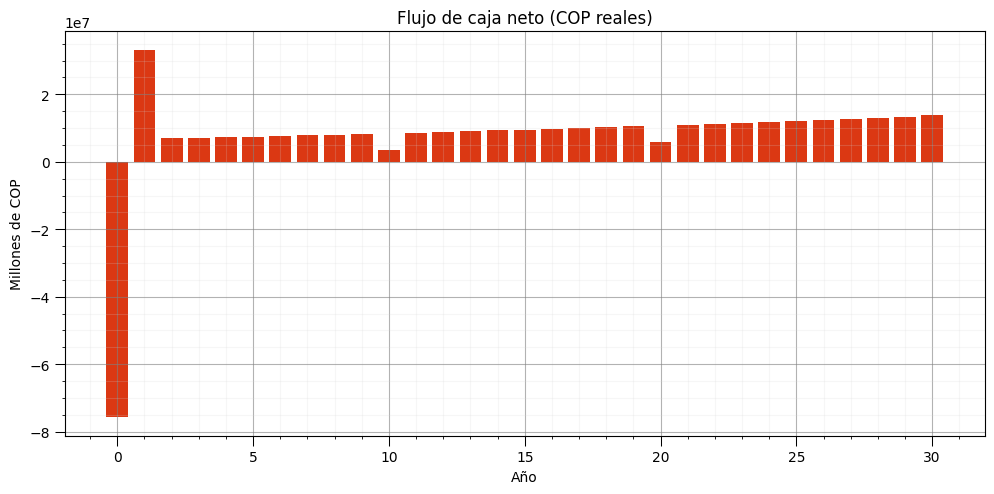

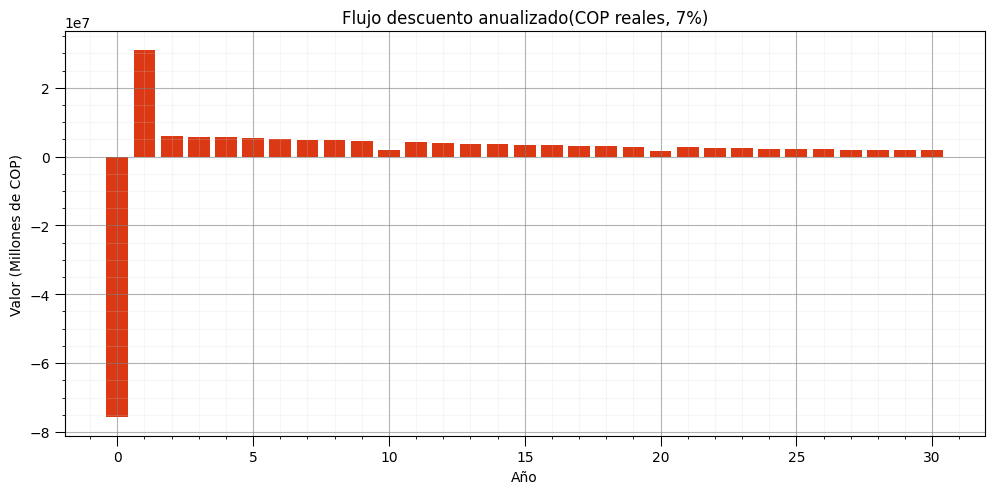

In [ ]:
plt.figure(figsize=(10,5))
plt.bar(df_years["Año"], df_years["Flujo Neto COP"], color='#DB3813')
plt.title("Flujo de caja neto (COP reales)")
plt.xlabel("Año")
plt.ylabel("Millones de COP")
plt.tight_layout()
plt.grid(True)
plt.tick_params(direction='out', length=7, width=0.75, grid_alpha=0.6)
plt.grid()
plt.grid(visible=True, which='major', color='grey', linestyle='-')
plt.minorticks_on()
plt.grid(visible=True, which='minor', color='lightgrey', linestyle='-', alpha=0.2)
plt.show()


plt.figure(figsize=(10,5))
plt.bar(df_years["Año"], df_years["Flujo descuento COP"], color='#DB3813')
plt.title("Flujo descuento anualizado(COP reales, 7%)")
plt.xlabel("Año")
plt.ylabel("Valor (Millones de COP)")
plt.tight_layout()
plt.grid(True)
plt.tick_params(direction='out', length=7, width=0.75, grid_alpha=0.6)
plt.grid()
plt.grid(visible=True, which='major', color='grey', linestyle='-')
plt.minorticks_on()
plt.grid(visible=True, which='minor', color='lightgrey', linestyle='-', alpha=0.2)
plt.show()

<strong><font color='black'><u><h1><left>Análisis:</left><h1></font></strong>

<font color='black'><left>
Teniendo en cuenta los supuestos del caso, el proyecto fotovoltaico resulta atractivo y viable. Los resultados muestran un VPN de 53,8 millones de COP, una TIR real cercana al 14,5 %, un payback descontado de alrededor de 12 años y un LCOE de 456 COP/kWh. Este LCOE se ubica por debajo de la tarifa vigente, lo que respalda que el ahorro unitario es competitivo desde el principioo. A nivel de caja, los años 10 y 20 presentan descensos puntuales por el reemplazo del inversor, pero están internalizadas y no comprometen la rentabilidad global.

Sin los incentivos, el proyecto sigue siendo viable aunque  a menor escala. El VPN se reduce a aproximadamente 17,0 millones de COP, la TIR real baja a aproximadamente 8,6 %, el payback descontado se extiende a unos 22 años y el LCOE aumenta a 739 COP/kWh, por encima de la tarifa inicial. En este escenario, la creación de valor se basa en que la tarifa eléctrica crezca por encima de la degradación y el aumento del O&M depende más de la trayectoria futura de precios.
</left></font>

<font color='black'><left>
El efecto de los incentivos es bastante importante y opera en tres frentes. Primero, elevan el VPN en aproximadamente 36,9 millones de COP al adelantar beneficios en los años 0 y 1, lo que mejora el valor presente del proyecto. Segundo, incrementan la TIR real en cerca de 5,9 porciento, pasando de un retorno apenas superior a la tasa objetivo a uno mucho más alto. Tercero, recortan el payback descontado en unos 10 años y reducen el LCOE cerca de 38 %, llevándolo desde 739 hasta 456 COP/kWh. Todo lo anterior hace hace que el proyecto sea viable gracias a los incentivos.
</left></font>


<font color='black'><left>
La sensibilidad con crecimiento real cero en la tarifa y en el O&M confirma el rol que los incentivos son relevantes para este proyecto. Si las tarifas no crecen en términos reales, el proyecto con incentivos conservaría un VPN positivo cercano a 25,2 millones de COP y una TIR real de alrededor de 11,6 %, mientras que sin incentivos el VPN sería negativo, indicando que el proyecto ya no es viable financieramente.

En conclusión, con incentivos el proyecto es claramente viable, con un LCOE inferior a la tarifa, TIR real por encima del 10 % y un VPN positivo, incluso bajo una sensibilidad de tarifas planas en términos reales. Sin incentivos, la viabilidad existe pero es más dependiente de que las tarifas crezcan y de que los costos operativos se contengan, por lo que el retorno es más estrecho y el payback es bastante mayor.
</left></font>